# Markov 5 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

In [2]:
# ------------------------------------------------------------
# 1. Fetch Data (Bulletproof Method)
# ------------------------------------------------------------
print("Downloading XOM and CVX data...")
xom = yf.download("XOM", start="2018-01-01", end="2023-01-01", progress=False)
cvx = yf.download("CVX", start="2018-01-01", end="2023-01-01", progress=False)
col = 'Adj Close' if 'Adj Close' in xom.columns else 'Close'

data = pd.concat([xom[col], cvx[col]], axis=1)
data.columns = ['XOM', 'CVX']
data = data.dropna()

In [3]:
# ------------------------------------------------------------
# 2. Create Stationary Spread via Rolling OLS (60-Day Window)
# ------------------------------------------------------------
print("Calculating 60-Day Rolling Spread...")
window = 60
spread_series = pd.Series(index=data.index, dtype=float)

for i in range(window, len(data)):
    # Look back 60 days to find the relationship
    y_hist = data['XOM'].iloc[i-window:i]
    x_hist = sm.add_constant(data['CVX'].iloc[i-window:i])
    ols_model = sm.OLS(y_hist, x_hist).fit()
    
    # Calculate today's OOS spread using yesterday's beta
    current_x = np.array([1.0, data['CVX'].iloc[i]])
    expected_y = np.dot(current_x, ols_model.params)
    spread_series.iloc[i] = data['XOM'].iloc[i] - expected_y

data['Spread'] = spread_series
data = data.dropna()

Calculating 60-Day Rolling Spread...


In [4]:
# ------------------------------------------------------------
# 3. Walk-Forward Setup: Train (2018-2019) / Test (2020-2022)
# ------------------------------------------------------------
train_data = data.loc[:'2019-12-31']
test_data = data.loc['2020-01-01':]

print(f"Training Markov Model on {len(train_data)} days...")
train_model = MarkovAutoregression(
    train_data['Spread'], k_regimes=2, order=1, trend="c", 
    switching_ar=True, switching_variance=True
)
train_res = train_model.fit(search_reps=20, disp=False)

# Identify which state is Danger (highest variance)
params = dict(zip(train_res.model.param_names, train_res.params))
danger_state = 0 if params.get('sigma2[0]', 0) > params.get('sigma2[1]', 0) else 1

Training Markov Model on 443 days...


In [5]:
# ------------------------------------------------------------
# 4. Out-of-Sample Filter (No Look-Ahead Bias)
# ------------------------------------------------------------
print(f"Running Out-of-Sample Backtest on {len(test_data)} days...")
test_model = MarkovAutoregression(
    test_data['Spread'], k_regimes=2, order=1, trend="c", 
    switching_ar=True, switching_variance=True
)
# Apply TRAINED parameters to TEST data. 
# This strictly uses "filtered_marginal_probabilities".
test_res = test_model.filter(train_res.params)

# Align data (AR(1) drops the first row)
test_data_aligned = test_data.iloc[1:].copy()

probs = test_res.filtered_marginal_probabilities
if isinstance(probs, pd.DataFrame):
    probs = probs.values
test_data_aligned['Danger_Prob'] = probs[:, danger_state]

Running Out-of-Sample Backtest on 756 days...


In [6]:
# ------------------------------------------------------------
# 5. Trading Logic Engine
# ------------------------------------------------------------
# Calculate Rolling Z-Score (20-day) for entry/exit triggers
roll_mean = test_data_aligned['Spread'].rolling(20).mean()
roll_std = test_data_aligned['Spread'].rolling(20).std()
test_data_aligned['Z_Score'] = (test_data_aligned['Spread'] - roll_mean) / roll_std

positions = np.zeros(len(test_data_aligned))
current_pos = 0.0

for i in range(len(test_data_aligned)):
    p_danger = test_data_aligned['Danger_Prob'].iloc[i]
    z = test_data_aligned['Z_Score'].iloc[i]
    
    # We must wait for Z-score to populate
    if np.isnan(z):
        positions[i] = 0
        continue
        
    # --- The Core Bot Logic ---
    if p_danger > 0.50:
        current_pos = 0.0  # FULL LIQUIDATE: Regime is broken
    elif p_danger < 0.20:
        if z > 1.5:
            current_pos = -1.0  # Short Spread
        elif z < -1.5:
            current_pos = 1.0   # Long Spread
        elif abs(z) < 0.2:
            current_pos = 0.0   # Take Profit at mean
    else:
        # P(Danger) is between 20% and 50%
        # Reduce position size by half to manage risk during uncertainty
        current_pos = current_pos * 0.5 
        
    positions[i] = current_pos

test_data_aligned['Position'] = positions

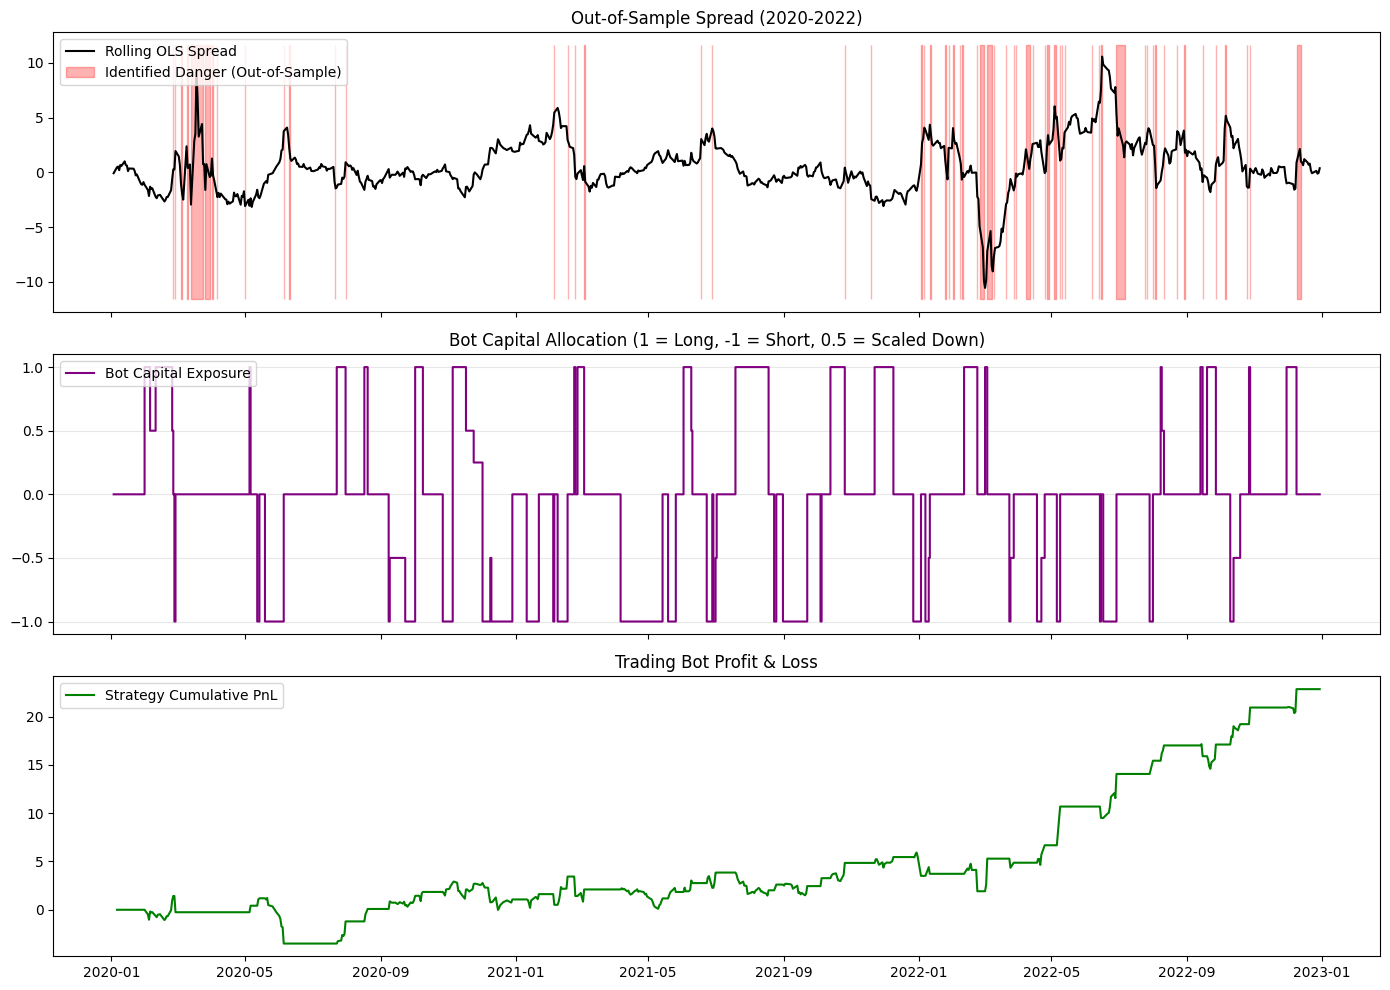


--- Training Parameters (2018-2019) ---
Calm Regime AR(1):   0.9686
Danger Regime AR(1): 0.8234


In [7]:
# ------------------------------------------------------------
# 6. Calculate PnL and Plot Results
# ------------------------------------------------------------
# Daily PnL = Position yesterday * Change in spread today
test_data_aligned['Spread_Change'] = test_data_aligned['Spread'].diff()
test_data_aligned['Strategy_PnL'] = test_data_aligned['Position'].shift(1) * test_data_aligned['Spread_Change']
test_data_aligned['Cum_PnL'] = test_data_aligned['Strategy_PnL'].cumsum()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Spread and Danger Regime
axes[0].plot(test_data_aligned.index, test_data_aligned['Spread'], color='black', label='Rolling OLS Spread')
axes[0].fill_between(test_data_aligned.index, axes[0].get_ylim()[0], axes[0].get_ylim()[1],
                     where=(test_data_aligned['Danger_Prob'] > 0.5), color='red', alpha=0.3, label='Identified Danger (Out-of-Sample)')
axes[0].set_title('Out-of-Sample Spread (2020-2022)')
axes[0].legend(loc='upper left')

# Panel 2: Bot Position Sizing
axes[1].plot(test_data_aligned.index, test_data_aligned['Position'], color='purple', drawstyle='steps-post', label='Bot Capital Exposure')
axes[1].set_title('Bot Capital Allocation (1 = Long, -1 = Short, 0.5 = Scaled Down)')
axes[1].set_yticks([-1, -0.5, 0, 0.5, 1])
axes[1].legend(loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

# Panel 3: Cumulative PnL
axes[2].plot(test_data_aligned.index, test_data_aligned['Cum_PnL'], color='green', label='Strategy Cumulative PnL')
axes[2].set_title('Trading Bot Profit & Loss')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

# Print out the corrected AR parameters
print("\n--- Training Parameters (2018-2019) ---")
print(f"Calm Regime AR(1):   {params.get(f'ar.L1[{1-danger_state}]', np.nan):.4f}")
print(f"Danger Regime AR(1): {params.get(f'ar.L1[{danger_state}]', np.nan):.4f}")